
# Uncertainty-aware Deep Learning with SNGP in PyTorch

This notebook rewrites the original TensorFlow SNGP demo in **PyTorch** using modern APIs.

Main changes:
- `tf.keras` → `torch.nn`
- TensorFlow spectral normalization → `torch.nn.utils.parametrizations.spectral_norm`
- TensorFlow random-feature GP head → a small custom PyTorch implementation of a **random Fourier feature GP classifier** with an online precision / covariance estimate
- `tf.keras.Model.fit(...)` → explicit PyTorch training loops with `DataLoader`, `optimizer.zero_grad(set_to_none=True)`, and `torch.inference_mode()` for evaluation

This version aims to preserve the **ideas and behavior** of the tutorial rather than reproduce TensorFlow internals exactly.



## Setup

This notebook assumes a recent PyTorch release (2.x). The spectral normalization API used here is the parametrization-based interface:

- `torch.nn.utils.parametrizations.spectral_norm`
- `torch.inference_mode()` for evaluation

The custom GP output layer below is a lightweight PyTorch reimplementation for tutorial use.


In [ ]:
# !pip install -r ../requirements.txt

In [ ]:

import math
import random
from dataclasses import dataclass

import matplotlib.colors as colors
import matplotlib.pyplot as plt
import numpy as np
import sklearn.datasets

import torch
import torch.nn as nn
from torch.nn.utils.parametrizations import spectral_norm
from torch.utils.data import DataLoader, TensorDataset

print(torch.__version__)


In [ ]:

plt.rcParams['figure.dpi'] = 140

DEFAULT_X_RANGE = (-3.5, 3.5)
DEFAULT_Y_RANGE = (-2.5, 2.5)
DEFAULT_CMAP = colors.ListedColormap(["#377eb8", "#ff7f00"])
DEFAULT_NORM = colors.Normalize(vmin=0, vmax=1)
DEFAULT_N_GRID = 100

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE


## Create the toy two-moons data

In [ ]:

def make_training_data(sample_size=500):
    """Create a two-moons training dataset."""
    # train_examples, train_labels = sklearn.datasets.make_circles(
    #     n_samples=2 * sample_size, factor=0.4, noise=0.05, random_state=SEED
    # )
    train_examples, train_labels = sklearn.datasets.make_moons(
        n_samples=2 * sample_size, noise=0.1, random_state=SEED
    )

    train_examples[train_labels == 0] += [-0.1, 0.2]
    train_examples[train_labels == 1] += [0.1, -0.2]
    return train_examples.astype(np.float32), train_labels.astype(np.int64)


def make_testing_data(x_range=DEFAULT_X_RANGE, y_range=DEFAULT_Y_RANGE, n_grid=DEFAULT_N_GRID):
    """Create a mesh grid in 2D space."""
    x = np.linspace(x_range[0], x_range[1], n_grid)
    y = np.linspace(y_range[0], y_range[1], n_grid)
    xv, yv = np.meshgrid(x, y)
    return np.stack([xv.flatten(), yv.flatten()], axis=-1).astype(np.float32)


def make_ood_data(sample_size=500, means=(2.5, -1.75), vars=(0.01, 0.01)):
    return np.random.multivariate_normal(
        means, cov=np.diag(vars), size=sample_size
    ).astype(np.float32)


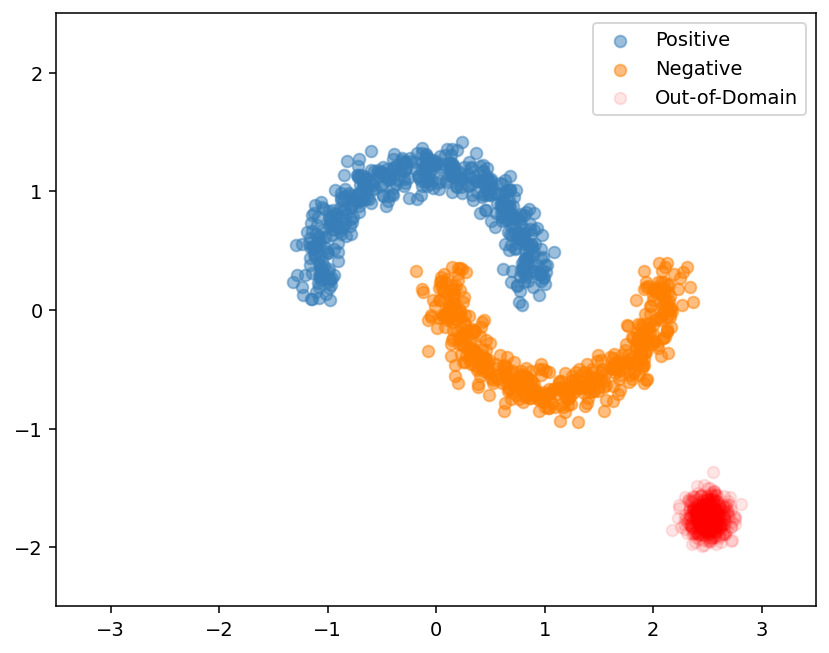

In [ ]:

train_examples, train_labels = make_training_data(sample_size=500)
test_examples = make_testing_data()
ood_examples = make_ood_data(sample_size=500)

pos_examples = train_examples[train_labels == 0]
neg_examples = train_examples[train_labels == 1]

plt.figure(figsize=(7, 5.5))
plt.scatter(pos_examples[:, 0], pos_examples[:, 1], c="#377eb8", alpha=0.5)
plt.scatter(neg_examples[:, 0], neg_examples[:, 1], c="#ff7f00", alpha=0.5)
plt.scatter(ood_examples[:, 0], ood_examples[:, 1], c="red", alpha=0.1)
plt.legend(["Positive", "Negative", "Out-of-Domain"])
plt.ylim(DEFAULT_Y_RANGE)
plt.xlim(DEFAULT_X_RANGE)
plt.show()


## Utilities

In [ ]:

def to_tensor(x, *, dtype=torch.float32, device=DEVICE):
    return torch.as_tensor(x, dtype=dtype, device=device)


def make_loader(x, y, batch_size=128, shuffle=True):
    dataset = TensorDataset(
        torch.as_tensor(x, dtype=torch.float32),
        torch.as_tensor(y, dtype=torch.long),
    )
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)


def accuracy_from_logits(logits, targets):
    preds = logits.argmax(dim=-1)
    return (preds == targets).float().mean().item()


def plot_uncertainty_surface(test_uncertainty, ax, cmap=None):
    """Visualize a 2D uncertainty surface."""
    test_uncertainty = np.asarray(test_uncertainty)
    test_uncertainty = test_uncertainty / np.maximum(test_uncertainty.max(), 1e-8)

    ax.set_ylim(DEFAULT_Y_RANGE)
    ax.set_xlim(DEFAULT_X_RANGE)

    pcm = ax.imshow(
        np.reshape(test_uncertainty, [DEFAULT_N_GRID, DEFAULT_N_GRID]),
        cmap=cmap,
        origin="lower",
        extent=DEFAULT_X_RANGE + DEFAULT_Y_RANGE,
        vmin=DEFAULT_NORM.vmin,
        vmax=DEFAULT_NORM.vmax,
        interpolation='bicubic',
        aspect='auto',
    )

    ax.scatter(train_examples[:, 0], train_examples[:, 1], c=train_labels, cmap=DEFAULT_CMAP, alpha=0.5)
    ax.scatter(ood_examples[:, 0], ood_examples[:, 1], c="red", alpha=0.1)
    return pcm


def plot_predictions(pred_probs, model_name=""):
    pred_probs = np.asarray(pred_probs)
    uncertainty = pred_probs * (1.0 - pred_probs)

    fig, axs = plt.subplots(1, 2, figsize=(14, 5))
    pcm_0 = plot_uncertainty_surface(pred_probs, ax=axs[0])
    pcm_1 = plot_uncertainty_surface(uncertainty, ax=axs[1])

    fig.colorbar(pcm_0, ax=axs[0])
    fig.colorbar(pcm_1, ax=axs[1])
    axs[0].set_title(f"Class Probability, {model_name}")
    axs[1].set_title(f"(Normalized) Predictive Uncertainty, {model_name}")
    plt.show()


## Baseline deterministic ResNet-style MLP

In [ ]:

class ResidualBlock(nn.Module):
    def __init__(self, hidden_dim: int, dropout_rate: float = 0.1, use_spectral_norm: bool = False):
        super().__init__()
        linear = nn.Linear(hidden_dim, hidden_dim)
        self.linear = spectral_norm(linear) if use_spectral_norm else linear
        self.activation = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, x):
        resid = self.linear(x)
        resid = self.activation(resid)
        resid = self.dropout(resid)
        return x + resid


class DeepResNet(nn.Module):
    def __init__(
        self,
        num_classes: int,
        num_layers: int = 6,
        num_hidden: int = 128,
        dropout_rate: float = 0.1,
        use_spectral_norm: bool = False,
    ):
        super().__init__()
        self.input_layer = nn.Linear(2, num_hidden)
        for param in self.input_layer.parameters():
            param.requires_grad = False

        self.blocks = nn.ModuleList([
            ResidualBlock(
                hidden_dim=num_hidden,
                dropout_rate=dropout_rate,
                use_spectral_norm=use_spectral_norm,
            )
            for _ in range(num_layers)
        ])
        self.classifier = nn.Linear(num_hidden, num_classes)

    def forward_features(self, x):
        hidden = self.input_layer(x)
        for block in self.blocks:
            hidden = block(hidden)
        return hidden

    def forward(self, x):
        hidden = self.forward_features(x)
        return self.classifier(hidden)


In [ ]:

resnet_config = dict(num_classes=2, num_layers=6, num_hidden=128, dropout_rate=0.1)

baseline_model = DeepResNet(**resnet_config).to(DEVICE)
baseline_model


DeepResNet(
  (input_layer): Linear(in_features=2, out_features=128, bias=True)
  (blocks): ModuleList(
    (0-5): 6 x ResidualBlock(
      (linear): Linear(in_features=128, out_features=128, bias=True)
      (activation): ReLU()
      (dropout): Dropout(p=0.1, inplace=False)
    )
  )
  (classifier): Linear(in_features=128, out_features=2, bias=True)
)

In [ ]:

@dataclass
class TrainConfig:
    lr: float = 1e-4
    weight_decay: float = 0.0
    batch_size: int = 128
    epochs: int = 100


train_config = TrainConfig()


In [ ]:

def train_classifier(model, x_train, y_train, config: TrainConfig, verbose=True):
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=config.lr,
        weight_decay=config.weight_decay,
    )
    criterion = nn.CrossEntropyLoss()
    loader = make_loader(x_train, y_train, batch_size=config.batch_size, shuffle=True)

    history = []
    for epoch in range(config.epochs):
        model.train()
        epoch_loss = 0.0
        epoch_acc = 0.0
        n_examples = 0

        for batch_x, batch_y in loader:
            batch_x = batch_x.to(DEVICE, non_blocking=True)
            batch_y = batch_y.to(DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            logits = model(batch_x)
            loss = criterion(logits, batch_y)
            loss.backward()
            optimizer.step()

            batch_size = batch_x.shape[0]
            epoch_loss += loss.item() * batch_size
            epoch_acc += accuracy_from_logits(logits.detach(), batch_y) * batch_size
            n_examples += batch_size

        metrics = {
            "epoch": epoch + 1,
            "loss": epoch_loss / n_examples,
            "acc": epoch_acc / n_examples,
        }
        history.append(metrics)
        if verbose and ((epoch + 1) % 20 == 0 or epoch == 0 or epoch + 1 == config.epochs):
            print(f"epoch={epoch+1:03d}  loss={metrics['loss']:.4f}  acc={metrics['acc']:.4f}")

    return history


def predict_proba_binary(model, x):
    model.eval()
    with torch.inference_mode():
        x = to_tensor(x, dtype=torch.float32)
        logits = model(x)
        probs = logits.softmax(dim=-1)[:, 0]
    return probs.detach().cpu().numpy()


epoch=001  loss=0.5318  acc=0.7130
epoch=020  loss=0.0270  acc=0.9920
epoch=040  loss=0.0057  acc=0.9990
epoch=060  loss=0.0021  acc=1.0000
epoch=080  loss=0.0010  acc=1.0000
epoch=100  loss=0.0005  acc=1.0000


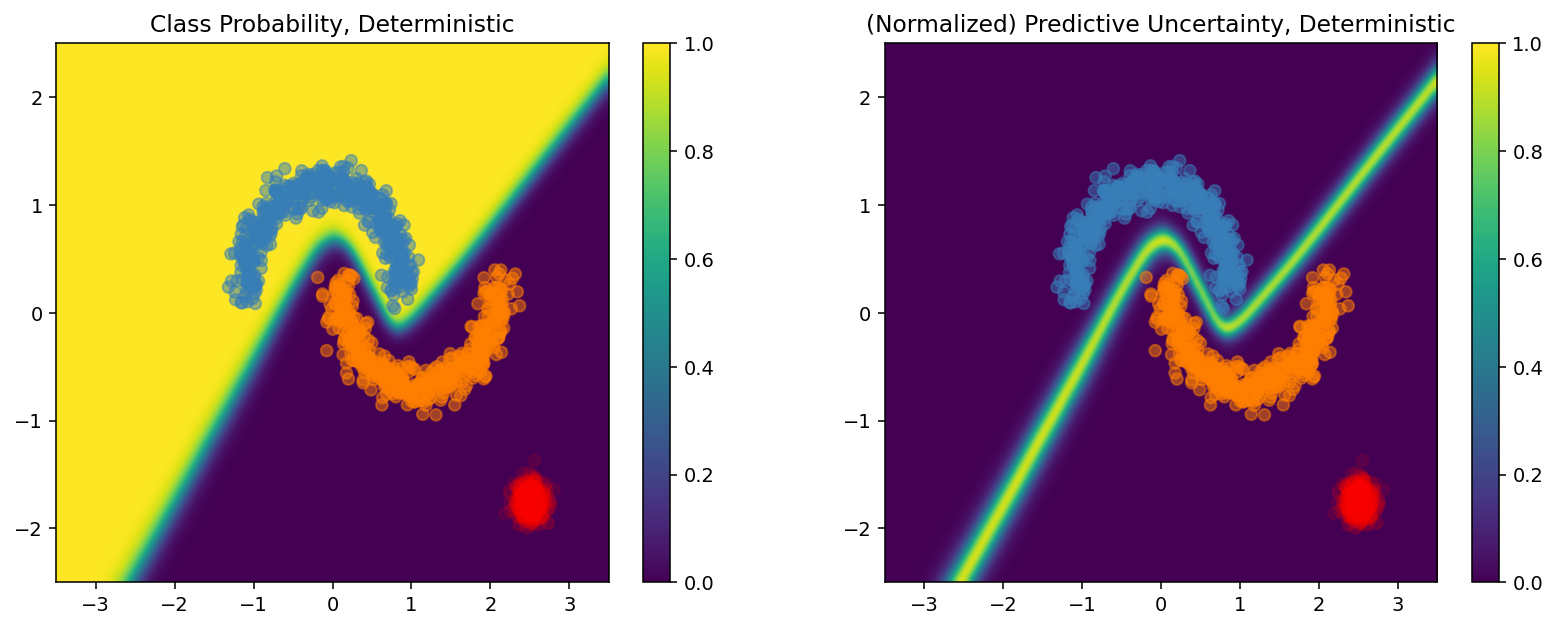

In [ ]:

_ = train_classifier(baseline_model, train_examples, train_labels, train_config)
resnet_probs = predict_proba_binary(baseline_model, test_examples)
plot_predictions(resnet_probs, model_name="Deterministic")



## SNGP components in PyTorch

SNGP combines two ideas:

1. **Spectral normalization** in the hidden layers.
2. A **Gaussian-process-style output layer**.

PyTorch has an official spectral-normalization parametrization API. For the GP head, this notebook uses a tutorial-friendly random Fourier feature approximation with an online precision matrix and a mean-field logit correction.


In [ ]:

example_dense = spectral_norm(nn.Linear(10, 10))
example_dense


ParametrizedLinear(
  in_features=10, out_features=10, bias=True
  (parametrizations): ModuleDict(
    (weight): ParametrizationList(
      (0): _SpectralNorm()
    )
  )
)

In [ ]:

class RandomFeatureGaussianProcess(nn.Module):
    """
    A lightweight random-feature GP classifier head.

    This is not a drop-in replacement for TensorFlow's official
    RandomFeatureGaussianProcess layer, but it follows the same core idea:
    map embeddings into random Fourier features, learn a linear head, and keep
    a running precision estimate for predictive covariance.
    """

    def __init__(
        self,
        in_features: int,
        out_features: int,
        num_inducing: int = 1024,
        ridge_penalty: float = 1.0,
        feature_scale: float = 1.0,
        gp_cov_momentum: float = -1.0,
        normalize_input: bool = False,
    ):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.num_inducing = num_inducing
        self.ridge_penalty = ridge_penalty
        self.feature_scale = feature_scale
        self.gp_cov_momentum = gp_cov_momentum
        self.normalize_input = normalize_input

        self.register_buffer(
            "random_weight",
            torch.randn(in_features, num_inducing) / math.sqrt(in_features),
        )
        self.register_buffer(
            "random_bias",
            2 * math.pi * torch.rand(num_inducing),
        )

        self.beta = nn.Linear(num_inducing, out_features, bias=True)
        self.register_buffer("precision_matrix", ridge_penalty * torch.eye(num_inducing))

    def reset_covariance_matrix(self):
        eye = torch.eye(self.num_inducing, device=self.precision_matrix.device, dtype=self.precision_matrix.dtype)
        self.precision_matrix.copy_(self.ridge_penalty * eye)

    def _random_features(self, x):
        if self.normalize_input:
            x = nn.functional.layer_norm(x, normalized_shape=(x.shape[-1],))
        projection = self.feature_scale * (x @ self.random_weight + self.random_bias)
        return math.sqrt(2.0 / self.num_inducing) * torch.cos(projection)

    @torch.no_grad()
    def _update_precision(self, phi):
        batch_precision = phi.T @ phi
        if self.gp_cov_momentum < 0:
            self.precision_matrix.add_(batch_precision)
        else:
            self.precision_matrix.mul_(self.gp_cov_momentum).add_(
                batch_precision, alpha=(1.0 - self.gp_cov_momentum)
            )

    def forward(self, x, return_cov=False, update_precision=False):
        phi = self._random_features(x)
        logits = self.beta(phi)

        if self.training and update_precision:
            self._update_precision(phi.detach())

        if not return_cov:
            return logits

        precision_inv = torch.linalg.pinv(self.precision_matrix)
        covmat = self.ridge_penalty * (phi @ precision_inv @ phi.T)
        return logits, covmat


In [ ]:

class DeepResNetSNGP(nn.Module):
    def __init__(
        self,
        num_classes: int,
        num_layers: int = 6,
        num_hidden: int = 128,
        dropout_rate: float = 0.1,
        spec_norm_bound: float = 0.95,  # kept for API compatibility / narrative
        num_inducing: int = 1024,
        ridge_penalty: float = 1.0,
        gp_cov_momentum: float = -1.0,
    ):
        super().__init__()
        self.spec_norm_bound = spec_norm_bound

        self.input_layer = nn.Linear(2, num_hidden)
        for param in self.input_layer.parameters():
            param.requires_grad = False

        self.blocks = nn.ModuleList([
            ResidualBlock(
                hidden_dim=num_hidden,
                dropout_rate=dropout_rate,
                use_spectral_norm=True,
            )
            for _ in range(num_layers)
        ])
        self.classifier = RandomFeatureGaussianProcess(
            in_features=num_hidden,
            out_features=num_classes,
            num_inducing=num_inducing,
            ridge_penalty=ridge_penalty,
            gp_cov_momentum=gp_cov_momentum,
            normalize_input=False,
        )

    def forward_features(self, x):
        hidden = self.input_layer(x)
        for block in self.blocks:
            hidden = block(hidden)
        return hidden

    def forward(self, x, return_cov=False, update_precision=False):
        hidden = self.forward_features(x)
        return self.classifier(hidden, return_cov=return_cov, update_precision=update_precision)


In [ ]:

def mean_field_logits(logits, covmat, lambda_param=np.pi / 8.0):
    variances = torch.diagonal(covmat, dim1=-2, dim2=-1).unsqueeze(-1)
    return logits / torch.sqrt(1.0 + lambda_param * variances)


def compute_posterior_mean_probability(logits, covmat, lambda_param=np.pi / 8.0):
    adjusted_logits = mean_field_logits(logits, covmat, lambda_param=lambda_param)
    return adjusted_logits.softmax(dim=-1)[:, 0]


In [ ]:

def train_sngp(model, x_train, y_train, config: TrainConfig, verbose=True):
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=config.lr, weight_decay=config.weight_decay)
    criterion = nn.CrossEntropyLoss()
    loader = make_loader(x_train, y_train, batch_size=config.batch_size, shuffle=True)

    history = []
    for epoch in range(config.epochs):
        model.train()
        model.classifier.reset_covariance_matrix()

        epoch_loss = 0.0
        epoch_acc = 0.0
        n_examples = 0

        for batch_x, batch_y in loader:
            batch_x = batch_x.to(DEVICE, non_blocking=True)
            batch_y = batch_y.to(DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            logits = model(batch_x, update_precision=True)
            loss = criterion(logits, batch_y)
            loss.backward()
            optimizer.step()

            batch_size = batch_x.shape[0]
            epoch_loss += loss.item() * batch_size
            epoch_acc += accuracy_from_logits(logits.detach(), batch_y) * batch_size
            n_examples += batch_size

        metrics = {
            "epoch": epoch + 1,
            "loss": epoch_loss / n_examples,
            "acc": epoch_acc / n_examples,
        }
        history.append(metrics)
        if verbose and ((epoch + 1) % 20 == 0 or epoch == 0 or epoch + 1 == config.epochs):
            print(f"epoch={epoch+1:03d}  loss={metrics['loss']:.4f}  acc={metrics['acc']:.4f}")

    return history


def predict_sngp(model, x):
    model.eval()
    with torch.inference_mode():
        x = to_tensor(x, dtype=torch.float32)
        logits, covmat = model(x, return_cov=True)
        probs = compute_posterior_mean_probability(logits, covmat)
    return (
        probs.detach().cpu().numpy(),
        logits.detach().cpu(),
        covmat.detach().cpu(),
    )


epoch=001  loss=0.6799  acc=0.6880
epoch=020  loss=0.4075  acc=0.9860
epoch=040  loss=0.2367  acc=0.9970
epoch=060  loss=0.1496  acc=0.9990
epoch=080  loss=0.1013  acc=1.0000
epoch=100  loss=0.0731  acc=1.0000


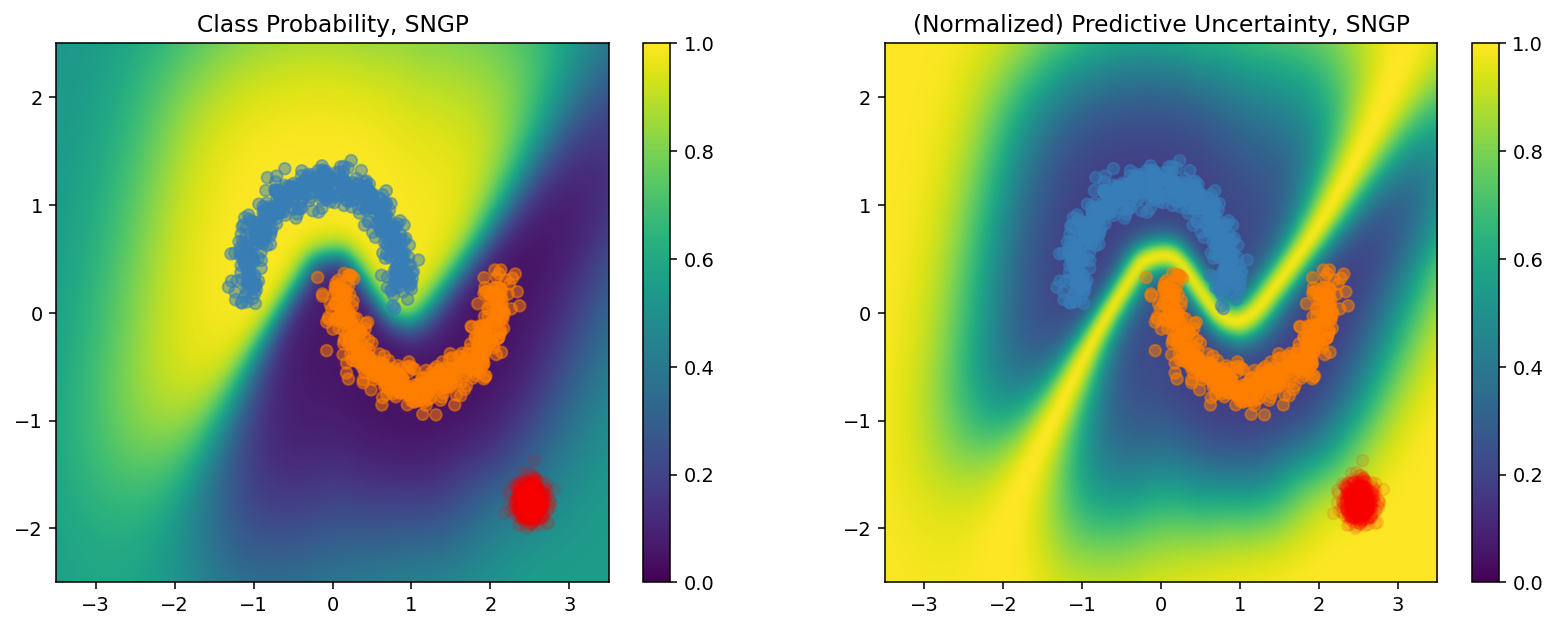

In [ ]:

sngp_model = DeepResNetSNGP(**resnet_config).to(DEVICE)
_ = train_sngp(sngp_model, train_examples, train_labels, train_config)
sngp_probs, sngp_logits, sngp_covmat = predict_sngp(sngp_model, test_examples)
plot_predictions(sngp_probs, model_name="SNGP")


## Compare deterministic model and SNGP

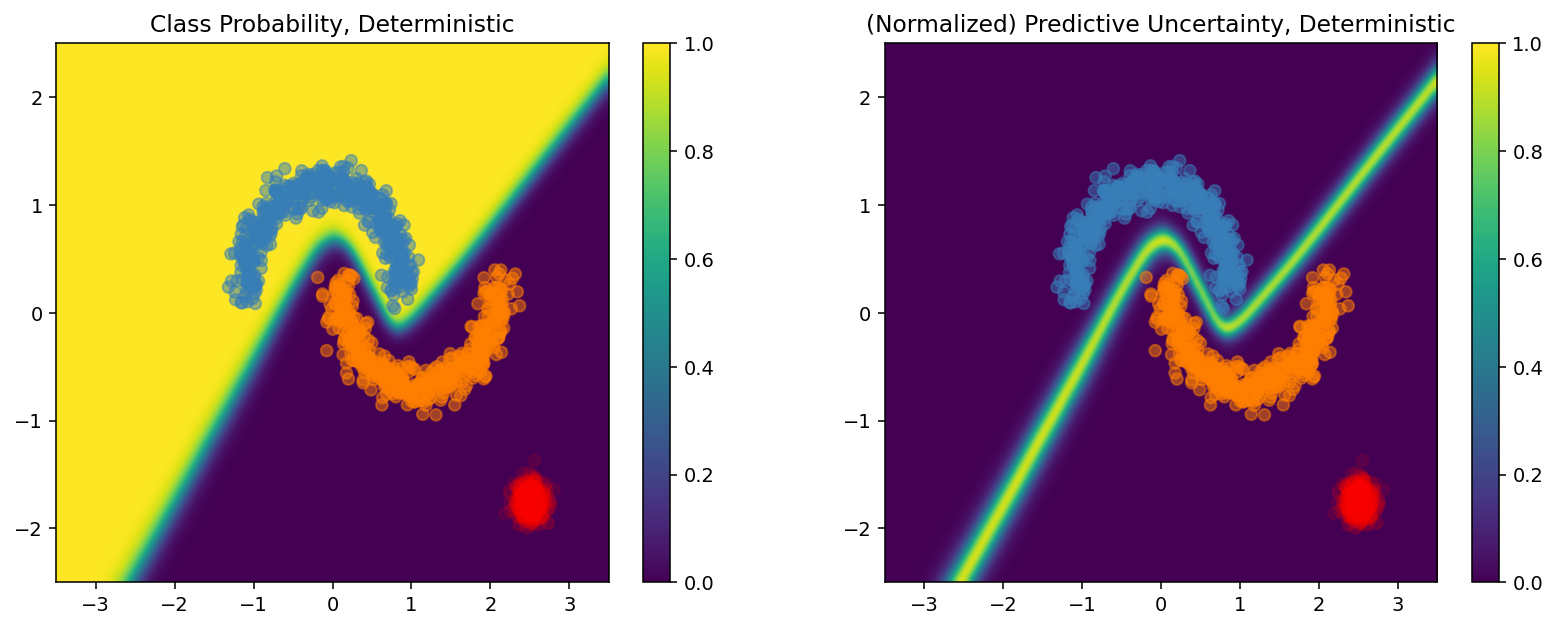

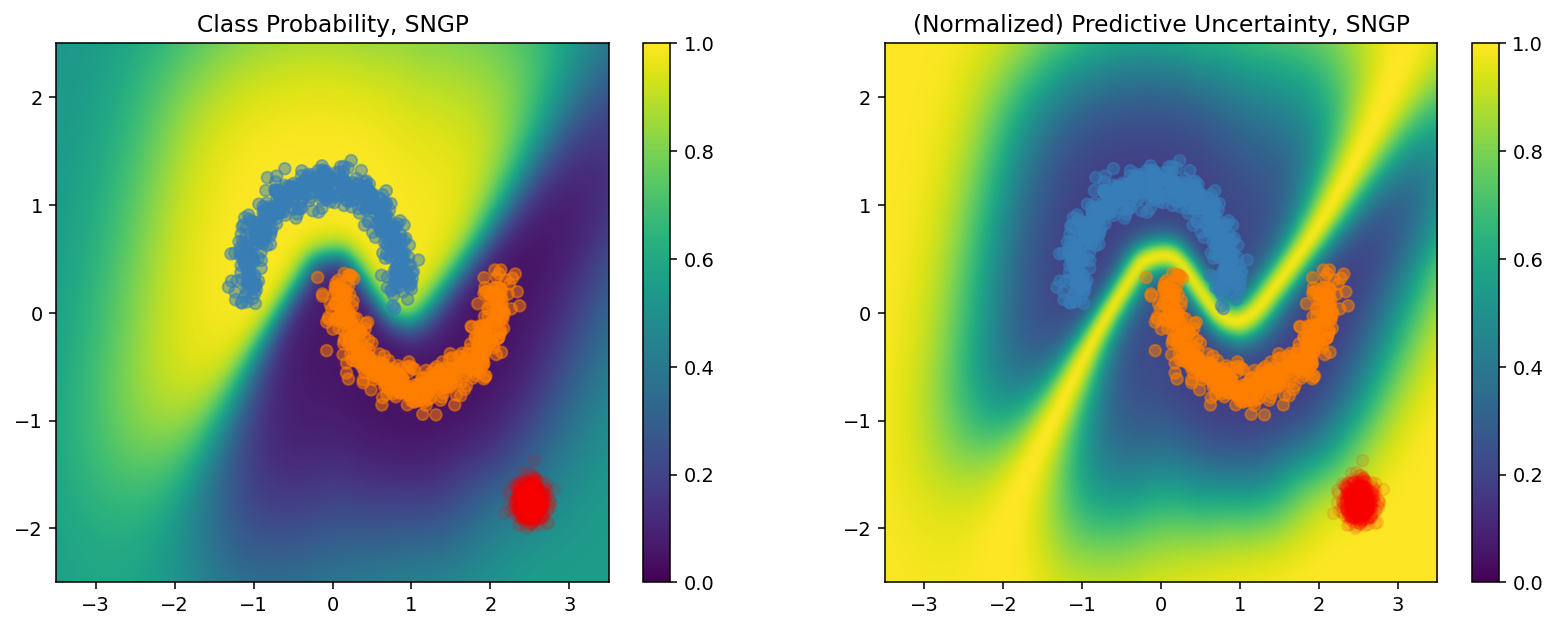

In [ ]:

plot_predictions(resnet_probs, model_name="Deterministic")
plot_predictions(sngp_probs, model_name="SNGP")


## Monte Carlo dropout baseline

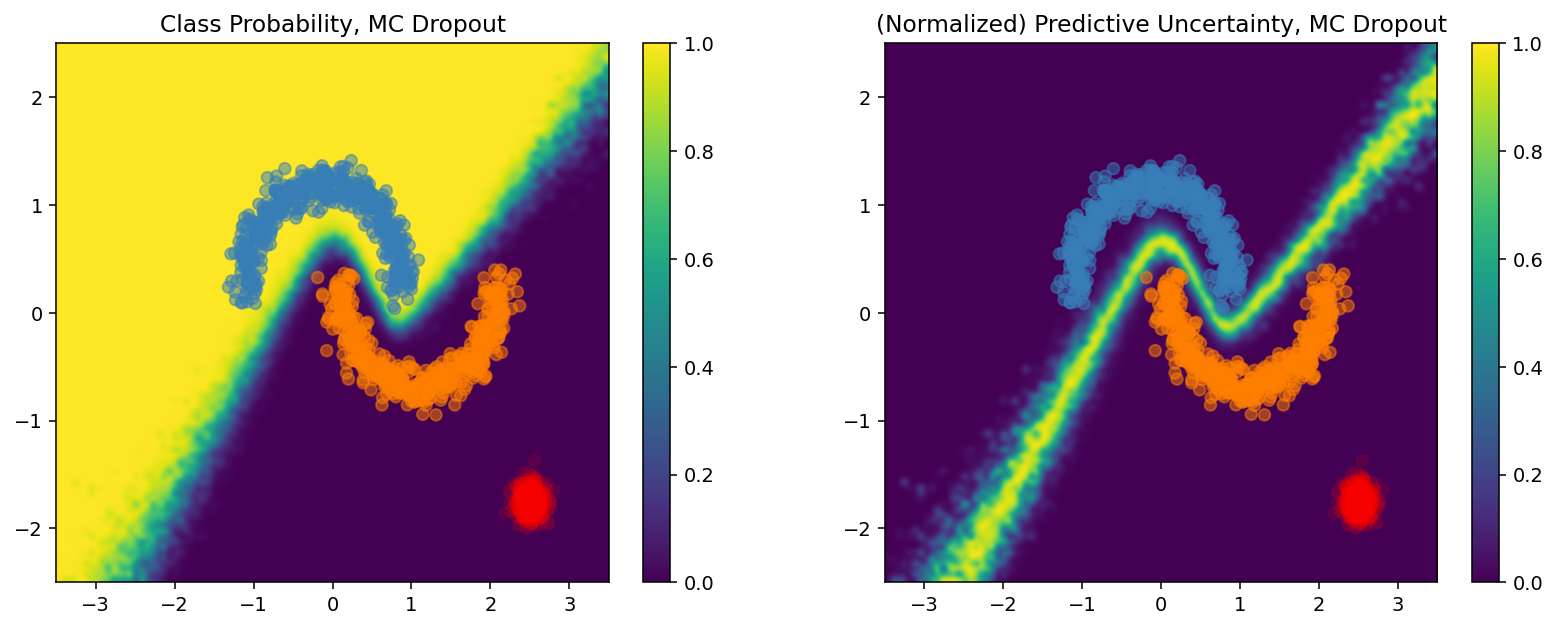

In [ ]:

num_ensemble = 10


def mc_dropout_sampling(model, x):
    model.train()  # keep dropout active
    with torch.inference_mode():
        x = to_tensor(x, dtype=torch.float32)
        logits = model(x)
        probs = logits.softmax(dim=-1)[:, 0]
    return probs.detach().cpu().numpy()


dropout_prob_samples = [mc_dropout_sampling(baseline_model, test_examples) for _ in range(num_ensemble)]
dropout_probs = np.mean(dropout_prob_samples, axis=0)
plot_predictions(dropout_probs, model_name="MC Dropout")


## Deep ensemble baseline

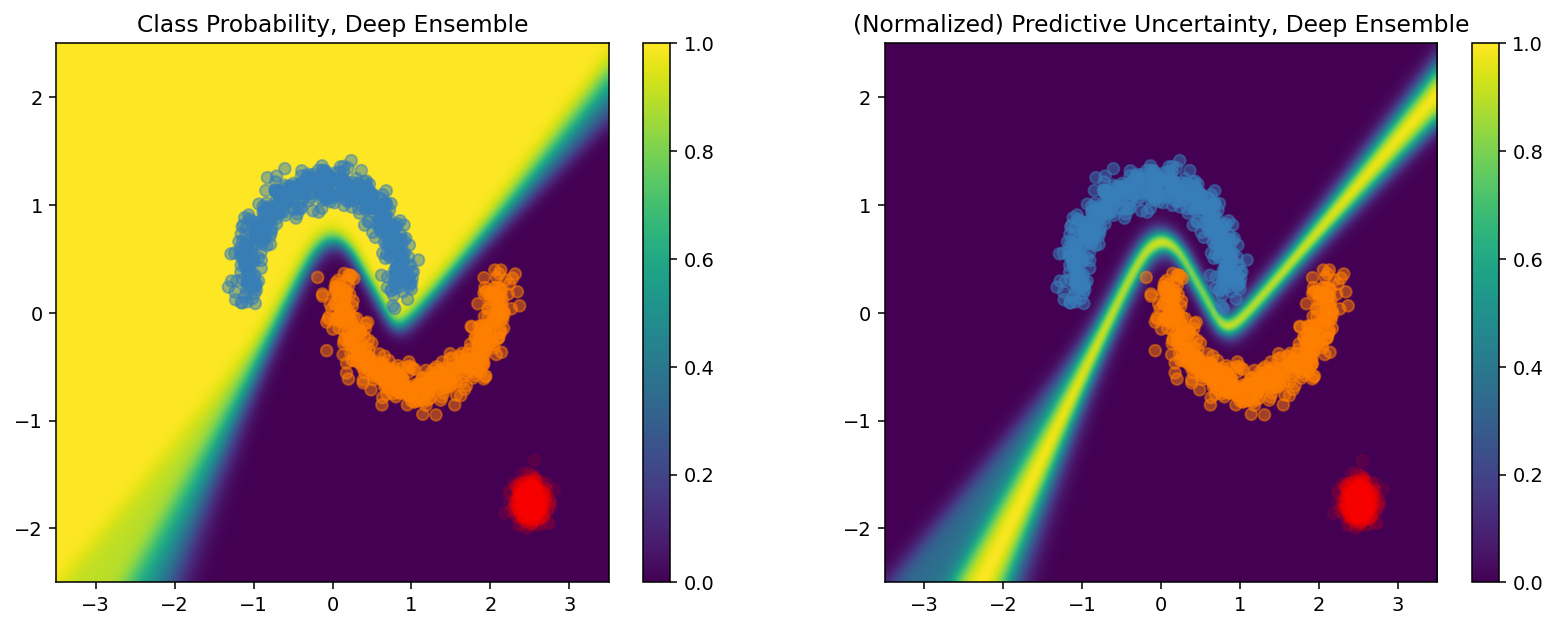

In [ ]:

resnet_ensemble = []
for seed in range(num_ensemble):
    torch.manual_seed(SEED + seed)
    model = DeepResNet(**resnet_config).to(DEVICE)
    _ = train_classifier(model, train_examples, train_labels, train_config, verbose=False)
    resnet_ensemble.append(model)

with torch.inference_mode():
    ensemble_prob_samples = [predict_proba_binary(model, test_examples) for model in resnet_ensemble]
ensemble_probs = np.mean(ensemble_prob_samples, axis=0)
plot_predictions(ensemble_probs, model_name="Deep Ensemble")



## Notes

A few implementation notes for this PyTorch rewrite:

- The **spectral normalization** wrapper is the modern parametrization API.
- The GP head here is a **custom approximation** designed for readability and experimentation.
- The TensorFlow tutorial's `RandomFeatureGaussianProcess` layer has extra details and engineering choices that are not reproduced exactly.
- The mean-field correction follows the same practical form used in SNGP-style demos:
  \( 	ext{logits} / \sqrt{1 + \lambda \cdot 	ext{variance}} \).

For research use, you may want to tune:
- `num_inducing`
- `ridge_penalty`
- `gp_cov_momentum`
- batch size and learning rate
- the random feature scaling scheme
